# 📡 Telco Customer Churn — EDA 분석 노트북

> **구성 순서**
> 1. 라이브러리 & 데이터 로드
> 2. 데이터 전체 현황 한눈에 보기 (모든 변수 차트)
> 3. 핵심 심화 분석 (비즈니스 인사이트 중심)
> 4. 지도 시각화 (지역별 이탈 현황)
> 5. 고급 시각화 (인터랙티브)
> 6. EDA 종합 요약


## 0. 라이브러리 & 데이터 로드

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 설정 (Windows: Malgun Gothic / Mac: AppleGothic)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
sns.set_style('whitegrid')

# ── 데이터 로드 ──────────────────────────────────────────
df = pd.read_csv('Telco_customer_churn.csv')

# Total Charges: 공백 포함 문자열 → float 변환
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce').fillna(0)

# Churn Reason: 이탈 사유 있으면 1, 없으면 0 (파생 변수)
df['Has Churn Reason'] = df['Churn Reason'].apply(lambda x: 0 if pd.isna(x) else 1)

# 이탈 사유 대분류 파생 변수
def categorize_reason(reason):
    if pd.isna(reason): return '해당없음(유지)'
    r = reason.lower()
    if 'competitor' in r:           return '경쟁사 이슈'
    elif 'attitude' in r or 'support' in r: return '서비스 태도'
    elif 'price' in r or 'expensive' in r:  return '가격 불만'
    elif 'network' in r or 'reliability' in r or 'speed' in r: return '네트워크 품질'
    elif 'product' in r or 'dissatisfaction' in r: return '상품 불만족'
    elif 'moved' in r: return '이사'
    else: return '기타/모름'

df['Churn Category'] = df['Churn Reason'].apply(categorize_reason)

print(f'데이터 크기: {df.shape}')
print(f'이탈 고객: {df["Churn Value"].sum():,}명 / 전체: {len(df):,}명 ({df["Churn Value"].mean()*100:.1f}%)')
df.head(3)


데이터 크기: (7043, 35)
이탈 고객: 1,869명 / 전체: 7,043명 (26.5%)


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason,Has Churn Reason,Churn Category
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer,1,경쟁사 이슈
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Electronic check,70.70,151.65,Yes,1,67,2701,Moved,1,이사
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Electronic check,99.65,820.50,Yes,1,86,5372,Moved,1,이사


## 1. 📋 데이터 전체 현황 한눈에 보기

> 모든 변수를 이탈 여부(Churn Label)와 함께 시각화합니다.
> 이 섹션 하나로 전체 데이터를 파악할 수 있습니다.


### 1-1. 결측치 현황

=== 결측치가 있는 컬럼 ===
              결측치 수  결측치 비율(%)
Churn Reason   5174      73.46


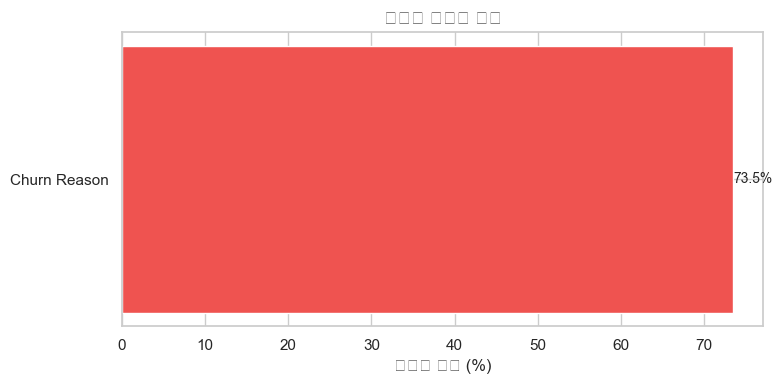


※ Churn Reason 결측치는 유지 고객(이탈 안 함)이라 정상입니다.


In [51]:
# 결측치 수와 비율을 함께 출력
missing = pd.DataFrame({
    '결측치 수': df.isnull().sum(),
    '결측치 비율(%)': (df.isnull().mean() * 100).round(2)
})
missing = missing[missing['결측치 수'] > 0]

print('=== 결측치가 있는 컬럼 ===')
if missing.empty:
    print('  결측치 없음 ✅')
else:
    print(missing)
    # 결측치 시각화
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.barh(missing.index, missing['결측치 비율(%)'], color='#EF5350', edgecolor='white')
    ax.set_xlabel('결측치 비율 (%)')
    ax.set_title('컬럼별 결측치 비율', fontsize=13, fontweight='bold')
    for bar in ax.patches:
        ax.text(bar.get_width()+0.1, bar.get_y()+bar.get_height()/2,
                f'{bar.get_width():.1f}%', va='center', fontsize=10)
    plt.tight_layout()
    plt.show()

# Churn Reason은 이탈하지 않은 고객이 NULL -> 정상
print('\n※ Churn Reason 결측치는 유지 고객(이탈 안 함)이라 정상입니다.')


### 1-2. 타겟 변수 — 이탈 여부 분포

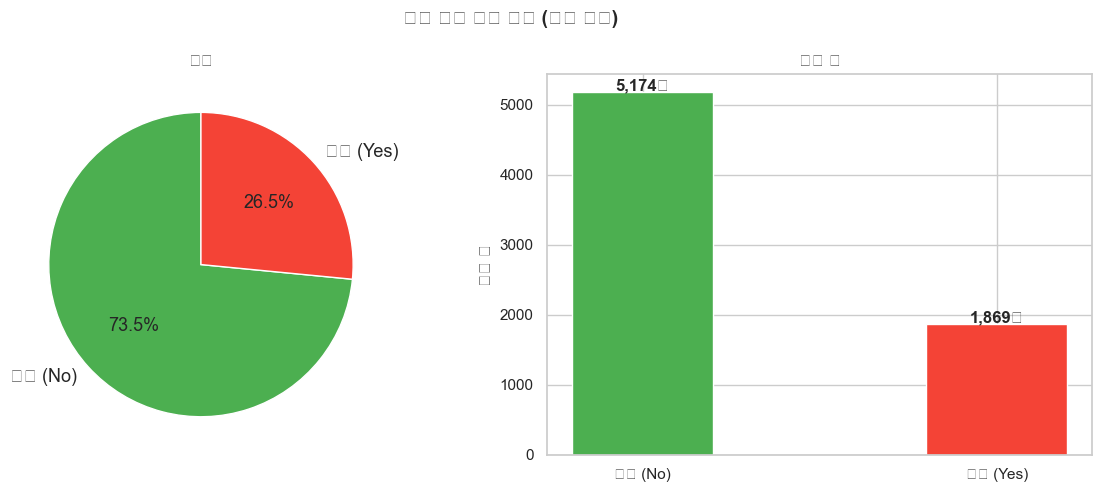

⚠️  이탈(26%) vs 유지(74%) 불균형 데이터 → 모델링 시 SMOTE 처리 필수!


In [52]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('고객 이탈 여부 분포 (타겟 변수)', fontsize=14, fontweight='bold')

vc = df['Churn Label'].value_counts()

# 파이 차트
axes[0].pie(vc, labels=['유지 (No)', '이탈 (Yes)'],
            colors=['#4CAF50', '#F44336'],
            autopct='%1.1f%%', startangle=90,
            textprops={'fontsize': 13})
axes[0].set_title('비율')

# 막대 그래프
bars = axes[1].bar(['유지 (No)', '이탈 (Yes)'], vc.values,
                   color=['#4CAF50', '#F44336'], edgecolor='white', width=0.4)
axes[1].set_title('고객 수')
axes[1].set_ylabel('고객 수')
for bar in bars:
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+30,
                 f'{bar.get_height():,}명', ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()
print(f'⚠️  이탈(26%) vs 유지(74%) 불균형 데이터 → 모델링 시 SMOTE 처리 필수!')


### 1-3. 수치형 변수 전체 — 이탈/유지 분포 비교

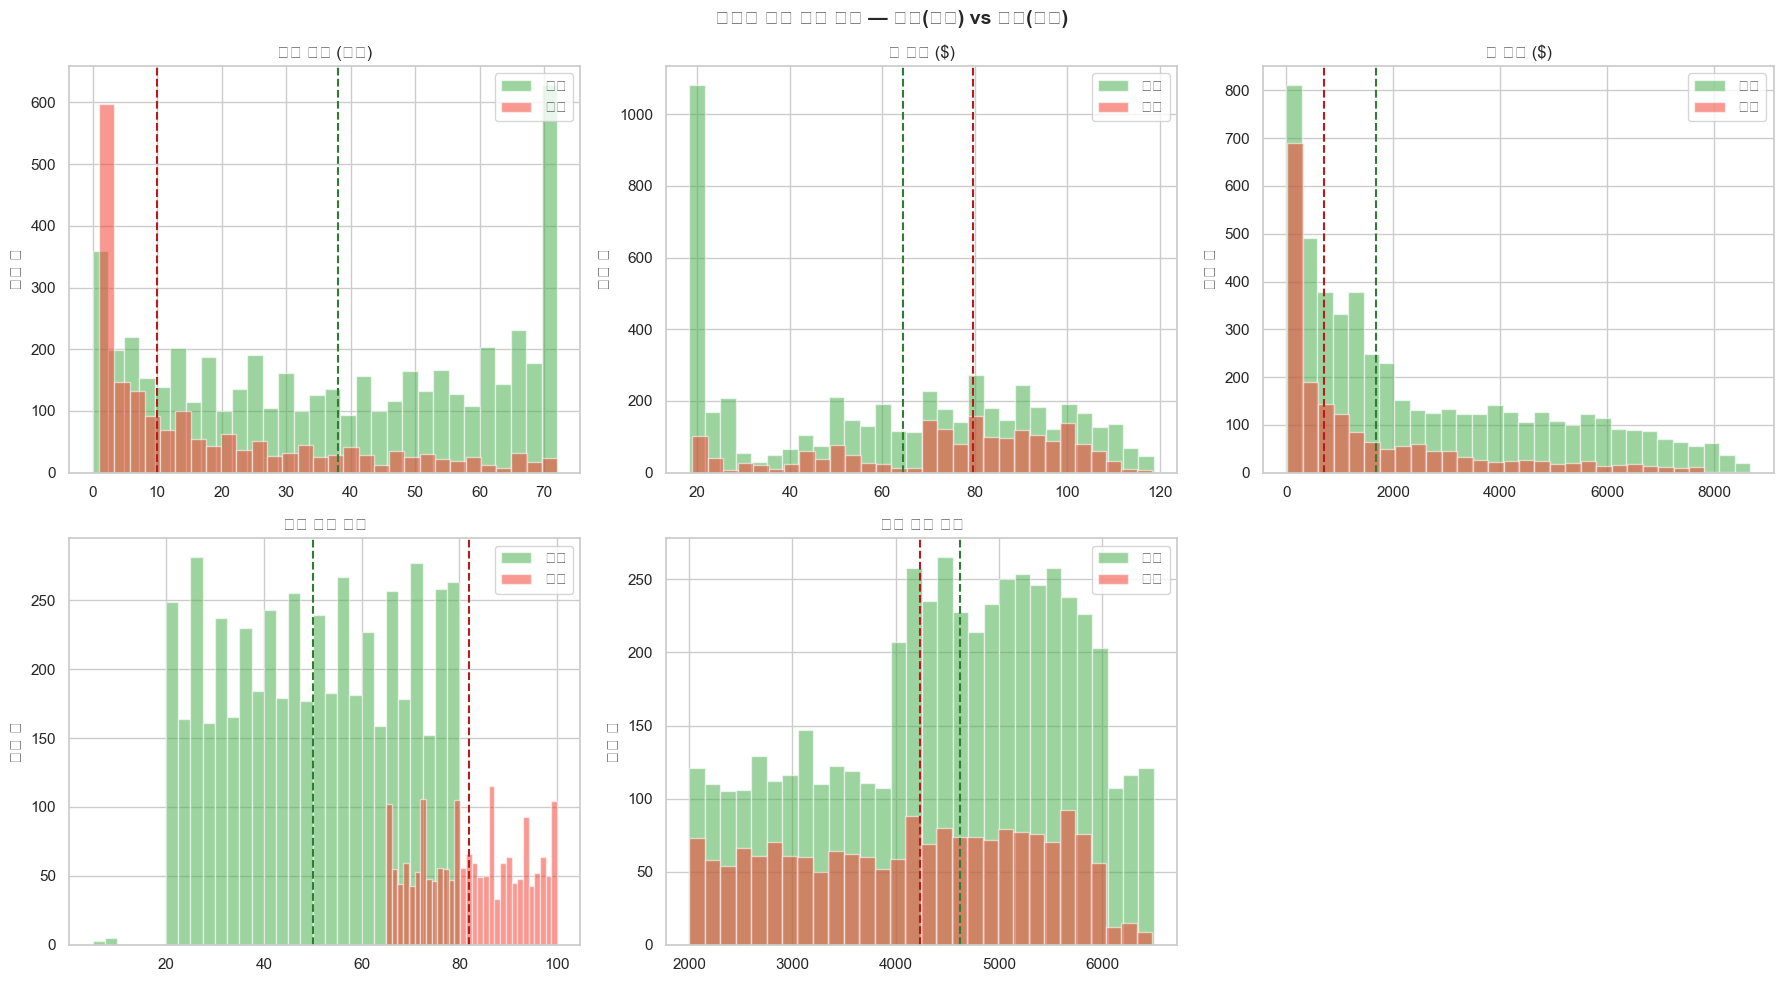

In [53]:
# 분석에 의미있는 수치형 변수만 선택
num_cols   = ['Tenure Months', 'Monthly Charges', 'Total Charges', 'Churn Score', 'CLTV']
num_labels = ['이용 기간 (개월)', '월 요금 ($)', '총 요금 ($)', '이탈 위험 점수', '고객 생애 가치']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('수치형 변수 전체 분포 — 이탈(빨강) vs 유지(초록)', fontsize=14, fontweight='bold')
axes = axes.flatten()

for i, (col, label) in enumerate(zip(num_cols, num_labels)):
    for churn, color, name in [('No','#4CAF50','유지'), ('Yes','#F44336','이탈')]:
        subset = df[df['Churn Label']==churn][col].dropna()
        axes[i].hist(subset, bins=30, alpha=0.55, color=color, label=name)
    # 이탈/유지 중앙값 점선 표시
    for churn, color in [('No','#2E7D32'), ('Yes','#B71C1C')]:
        med = df[df['Churn Label']==churn][col].median()
        axes[i].axvline(med, color=color, linestyle='--', linewidth=1.5)
    axes[i].set_title(label, fontsize=12)
    axes[i].set_ylabel('고객 수')
    axes[i].legend()

axes[-1].set_visible(False)  # 빈 subplot 숨기기
plt.tight_layout()
plt.show()


### 1-4. 이진형 변수 전체 — 이탈률(%) 비교

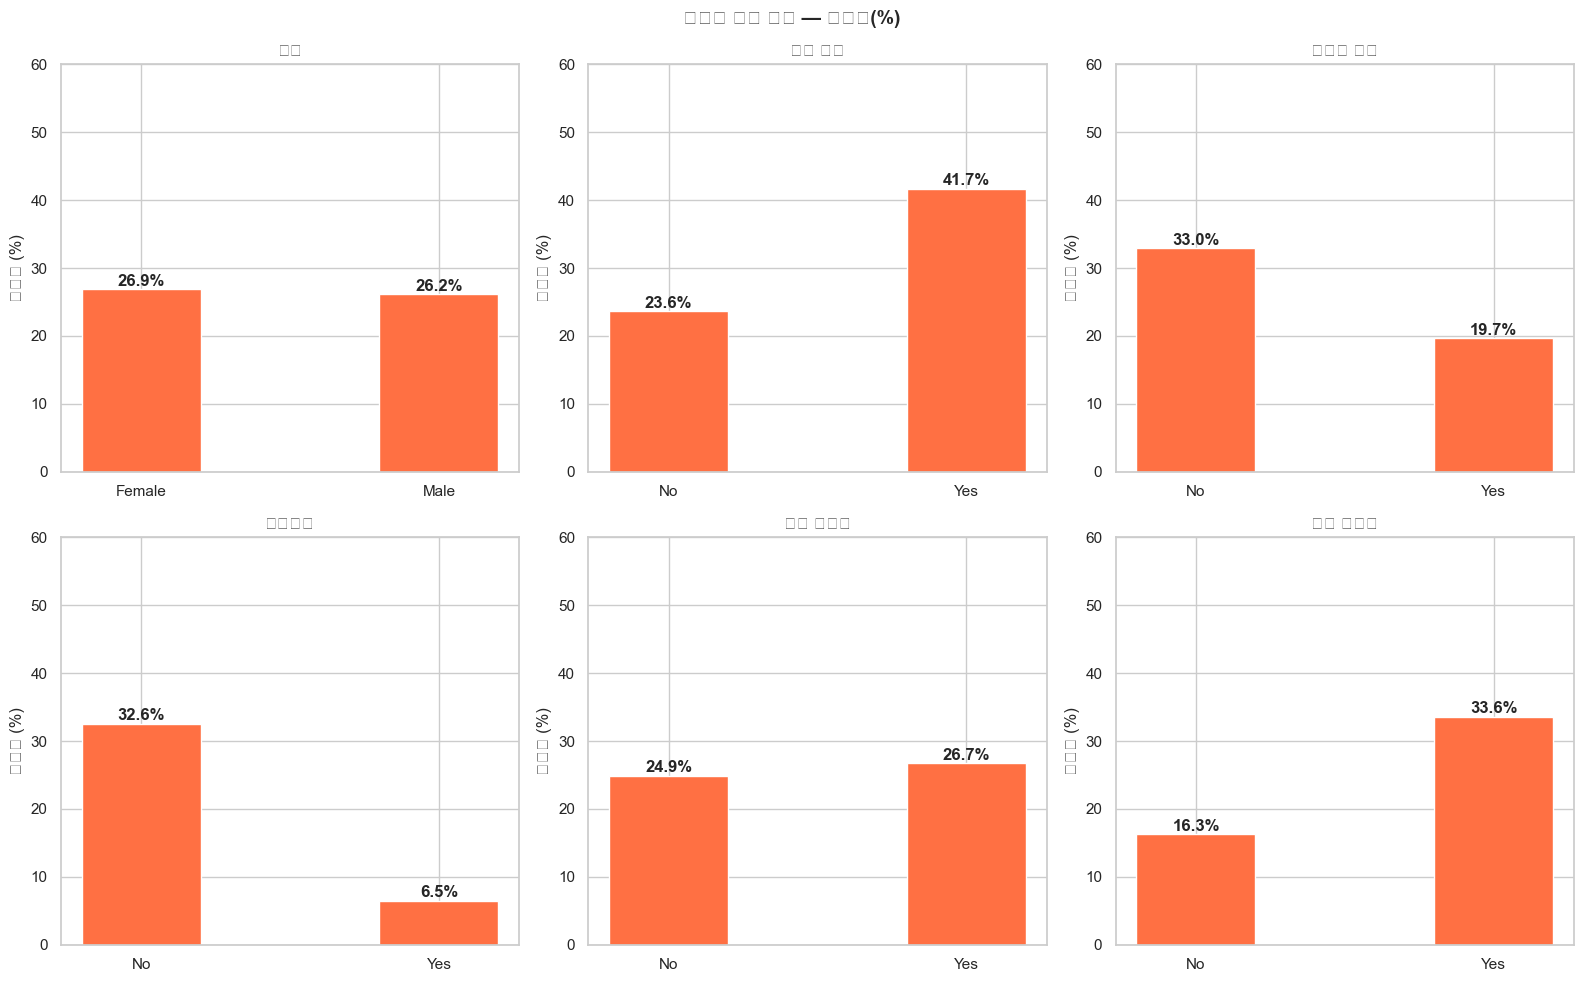

In [54]:
# 이진 변수 (Yes/No) 6개 이탈률 비교
binary_cols   = ['Gender', 'Senior Citizen', 'Partner', 'Dependents',
                 'Phone Service', 'Paperless Billing']
binary_labels = ['성별', '노인 여부', '파트너 동거', '부양가족', '전화 서비스', '전자 청구서']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('이진형 변수 전체 — 이탈률(%)', fontsize=14, fontweight='bold')
axes = axes.flatten()

for i, (col, label) in enumerate(zip(binary_cols, binary_labels)):
    rate = (df.groupby(col)['Churn Label']
              .apply(lambda x: (x=='Yes').mean()*100)
              .reset_index())
    rate.columns = [col, 'churn_rate']
    bars = axes[i].bar(rate[col].astype(str), rate['churn_rate'],
                       color='#FF7043', edgecolor='white', width=0.4)
    axes[i].set_title(label, fontsize=12)
    axes[i].set_ylabel('이탈률 (%)')
    axes[i].set_ylim(0, 60)
    for bar in bars:
        axes[i].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                     f'{bar.get_height():.1f}%', ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()


### 1-5. 다중 범주형 변수 전체 — 이탈률(%) 비교

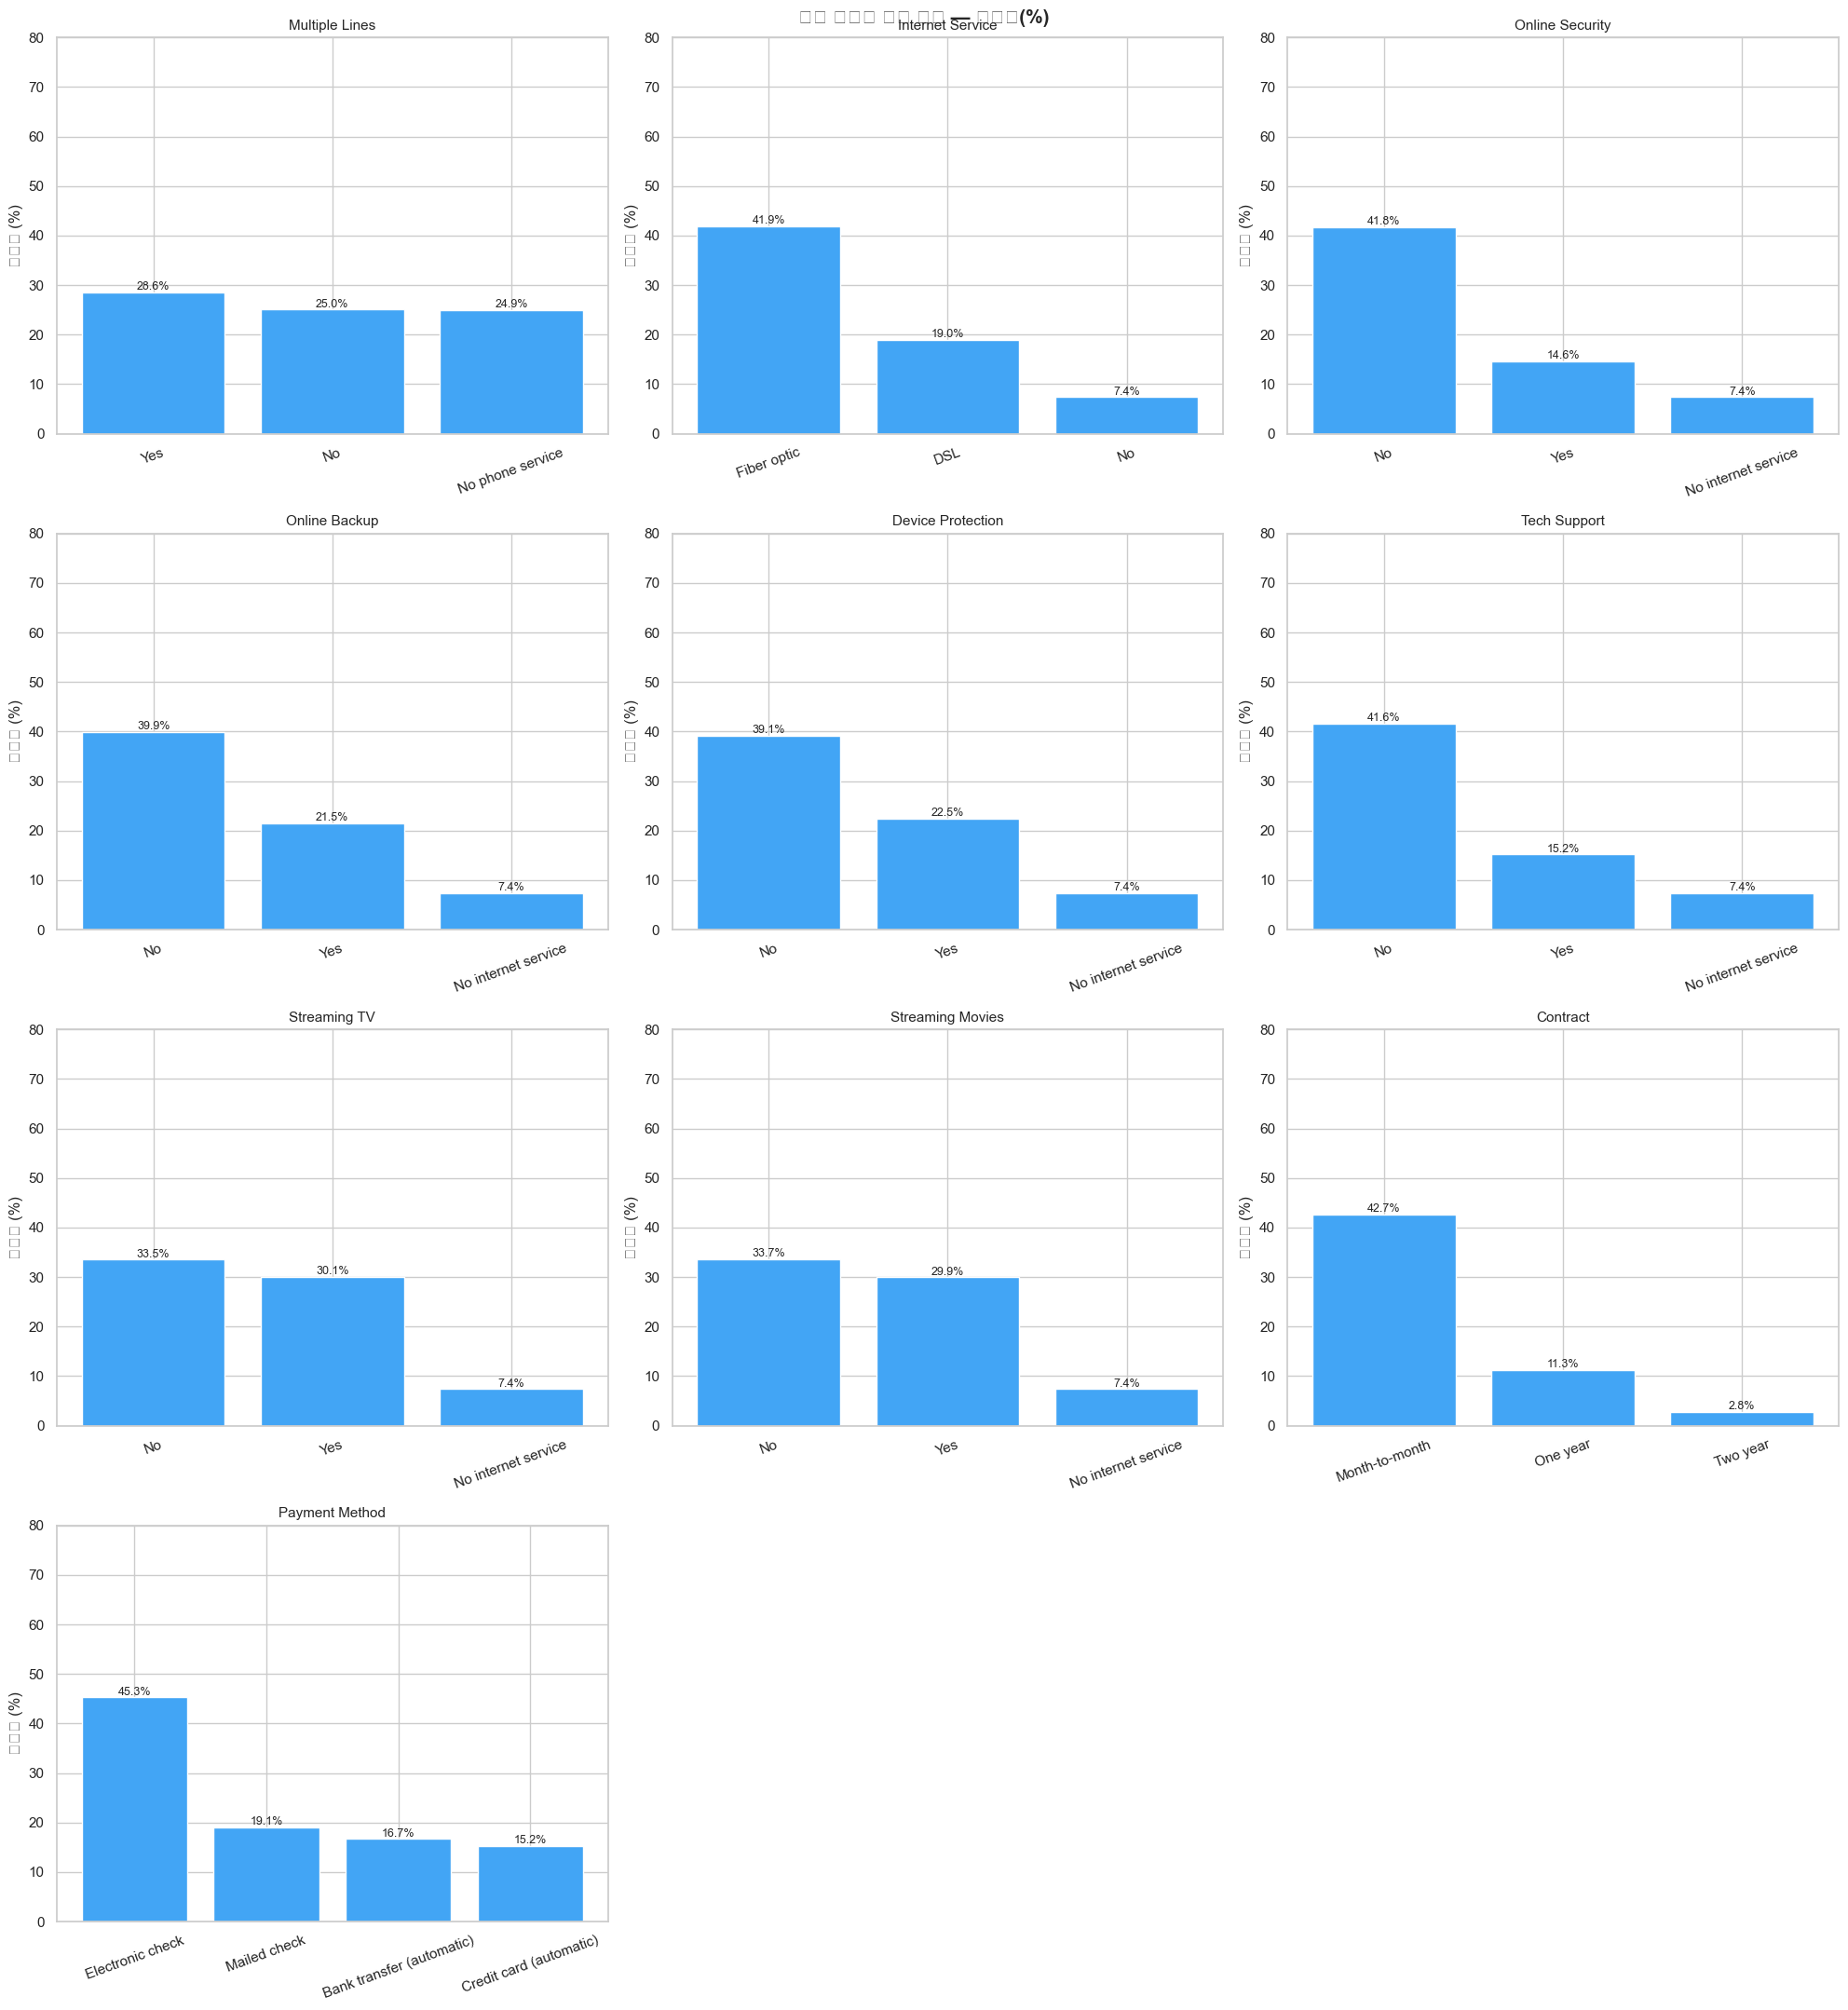

In [55]:
# 삼중/4중 범주형 변수 10개 이탈률 비교
multi_cols = [
    'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup',
    'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies',
    'Contract', 'Payment Method'
]

fig, axes = plt.subplots(4, 3, figsize=(20, 22))
fig.suptitle('다중 범주형 변수 전체 — 이탈률(%)', fontsize=15, fontweight='bold')
axes = axes.flatten()

for i, col in enumerate(multi_cols):
    rate = (df.groupby(col)['Churn Label']
              .apply(lambda x: (x=='Yes').mean()*100)
              .sort_values(ascending=False)
              .reset_index())
    rate.columns = [col, 'churn_rate']
    bars = axes[i].bar(rate[col].astype(str), rate['churn_rate'],
                       color='#42A5F5', edgecolor='white')
    axes[i].set_title(col, fontsize=11)
    axes[i].set_ylabel('이탈률 (%)')
    axes[i].set_ylim(0, 80)
    axes[i].tick_params(axis='x', rotation=20)
    for bar in bars:
        axes[i].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                     f'{bar.get_height():.1f}%', ha='center', fontsize=9)

for j in range(len(multi_cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()


## 2. 🔍 핵심 심화 분석 (비즈니스 인사이트 중심)

> 단순 분포 확인을 넘어 **왜 이탈하는가** 에 대한 인사이트를 뽑아냅니다.


### 2-1. 💰 비즈니스 임팩트 — 이탈로 인한 손실 금액

  이탈 고객 수          : 1,869명
  이탈 고객 평균 CLTV   : $4,149
  이탈로 인한 총 손실   : $7,755,256
  30% 방어 시 절약 가치 : $2,326,577


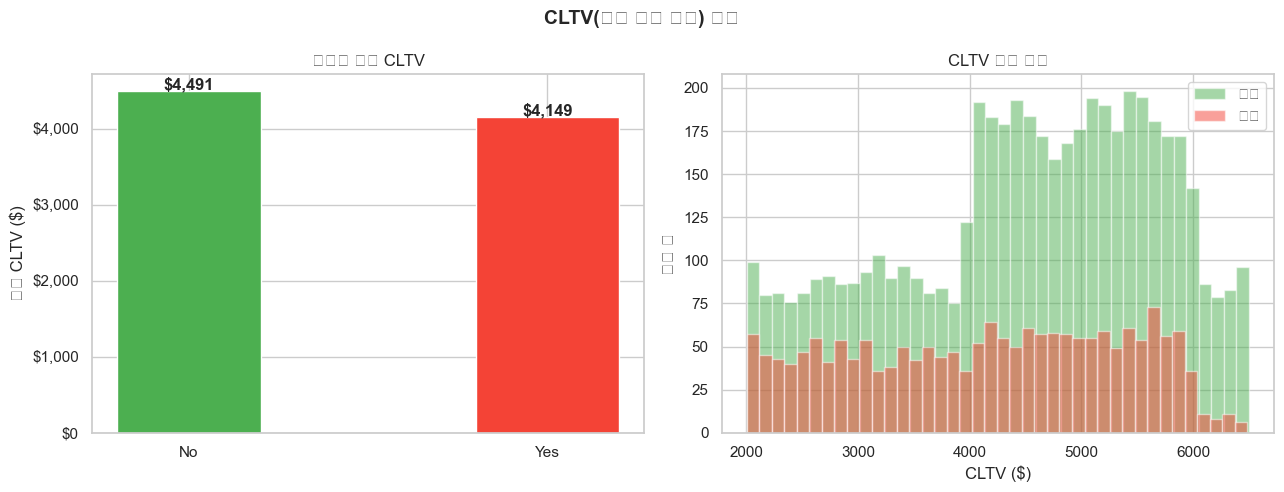

In [56]:
churn_df = df[df['Churn Value'] == 1]

total_loss = churn_df['CLTV'].sum()
avg_loss   = churn_df['CLTV'].mean()

print('=' * 55)
print(f'  이탈 고객 수          : {len(churn_df):,}명')
print(f'  이탈 고객 평균 CLTV   : ${avg_loss:,.0f}')
print(f'  이탈로 인한 총 손실   : ${total_loss:,}')
print(f'  30% 방어 시 절약 가치 : ${total_loss*0.3:,.0f}')
print('=' * 55)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('CLTV(고객 생애 가치) 분석', fontsize=14, fontweight='bold')

# 평균 CLTV 막대
cltv_avg = df.groupby('Churn Label')['CLTV'].mean().reset_index()
bars = axes[0].bar(cltv_avg['Churn Label'], cltv_avg['CLTV'],
                   color=['#4CAF50','#F44336'], edgecolor='white', width=0.4)
axes[0].set_title('그룹별 평균 CLTV')
axes[0].set_ylabel('평균 CLTV ($)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
for bar in bars:
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+30,
                 f'${bar.get_height():,.0f}', ha='center', fontsize=12, fontweight='bold')

# CLTV 분포 히스토그램
for label, color, name in [('No','#4CAF50','유지'),('Yes','#F44336','이탈')]:
    axes[1].hist(df[df['Churn Label']==label]['CLTV'],
                 bins=40, alpha=0.5, color=color, label=name)
axes[1].set_title('CLTV 분포 비교')
axes[1].set_xlabel('CLTV ($)')
axes[1].set_ylabel('고객 수')
axes[1].legend()

plt.tight_layout()
plt.show()


### 2-2. 📦 계약 유형 심화 — 교차표 + 이탈률

=== 계약 유형별 이탈 현황 ===
Churn Label       No   Yes  이탈률(%)
Contract                          
Month-to-month  2220  1655    42.7
One year        1307   166    11.3
Two year        1647    48     2.8


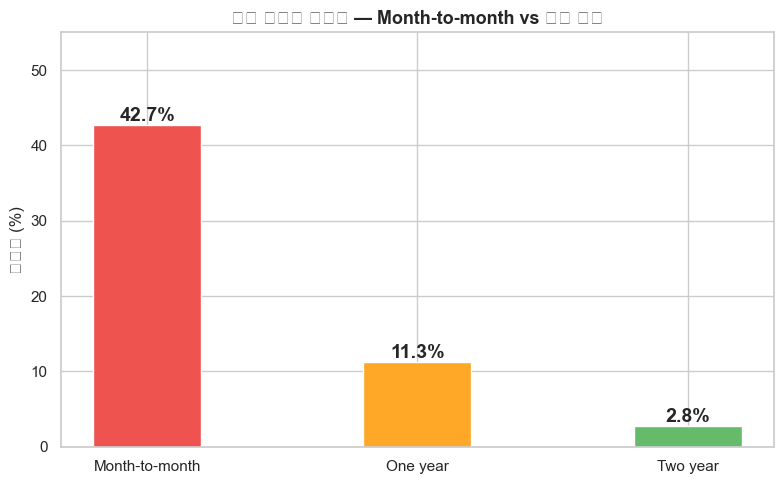

[핵심 인사이트]
Month-to-month 이탈률: 42.7%
Two year 이탈률:       2.8%
→ 무려 15배 차이!


In [57]:
# 정확한 수치를 교차표로 확인
ct = pd.crosstab(df['Contract'], df['Churn Label'])
ct['이탈률(%)'] = (ct['Yes'] / (ct['Yes']+ct['No']) * 100).round(1)
print('=== 계약 유형별 이탈 현황 ===')
print(ct)

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#EF5350', '#FFA726', '#66BB6A']
bars = ax.bar(ct.index, ct['이탈률(%)'], color=colors, edgecolor='white', width=0.4)
ax.set_title('계약 유형별 이탈률 — Month-to-month vs 장기 계약',
             fontsize=13, fontweight='bold')
ax.set_ylabel('이탈률 (%)')
ax.set_ylim(0, 55)
for bar in bars:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            f'{bar.get_height():.1f}%', ha='center', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('[핵심 인사이트]')
print(f'Month-to-month 이탈률: {ct.loc["Month-to-month","이탈률(%)"]:.1f}%')
print(f'Two year 이탈률:       {ct.loc["Two year","이탈률(%)"]:.1f}%')
print(f'→ 무려 {ct.loc["Month-to-month","이탈률(%)"]/ct.loc["Two year","이탈률(%)"]:.0f}배 차이!')


### 2-3. 💳 결제 방식 — 이탈률 + 실제 이탈 수

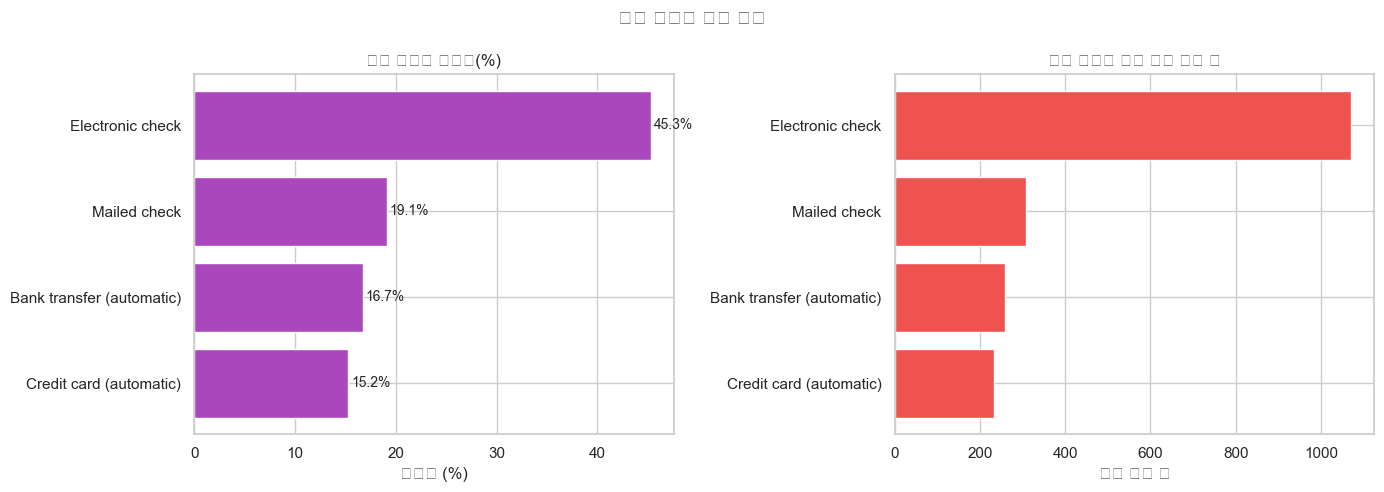

[핵심 인사이트]
- Electronic check: 이탈률 45% — 압도적 1위
- 자동 결제(Bank transfer/Credit card) 이탈률 낮음
  → 자동 결제 전환 유도가 이탈 방어 전략이 될 수 있음


In [58]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('결제 방식별 이탈 분석', fontsize=14, fontweight='bold')

pay_stats = df.groupby('Payment Method').agg(
    total=('Churn Value','count'),
    churned=('Churn Value','sum')
).reset_index()
pay_stats['churn_rate'] = pay_stats['churned'] / pay_stats['total'] * 100
pay_stats = pay_stats.sort_values('churn_rate', ascending=True)

# 이탈률 가로 막대
axes[0].barh(pay_stats['Payment Method'], pay_stats['churn_rate'],
             color='#AB47BC', edgecolor='white')
axes[0].set_title('결제 방식별 이탈률(%)')
axes[0].set_xlabel('이탈률 (%)')
for i, row in pay_stats.iterrows():
    axes[0].text(row['churn_rate']+0.3, list(pay_stats.index).index(i),
                 f'{row["churn_rate"]:.1f}%', va='center', fontsize=10)

# 실제 이탈 고객 수
axes[1].barh(pay_stats['Payment Method'], pay_stats['churned'],
             color='#EF5350', edgecolor='white')
axes[1].set_title('결제 방식별 실제 이탈 고객 수')
axes[1].set_xlabel('이탈 고객 수')

plt.tight_layout()
plt.show()

print('[핵심 인사이트]')
print('- Electronic check: 이탈률 45% — 압도적 1위')
print('- 자동 결제(Bank transfer/Credit card) 이탈률 낮음')
print('  → 자동 결제 전환 유도가 이탈 방어 전략이 될 수 있음')


### 2-4. 📊 수치형 변수 박스플롯 — 중앙값 비교

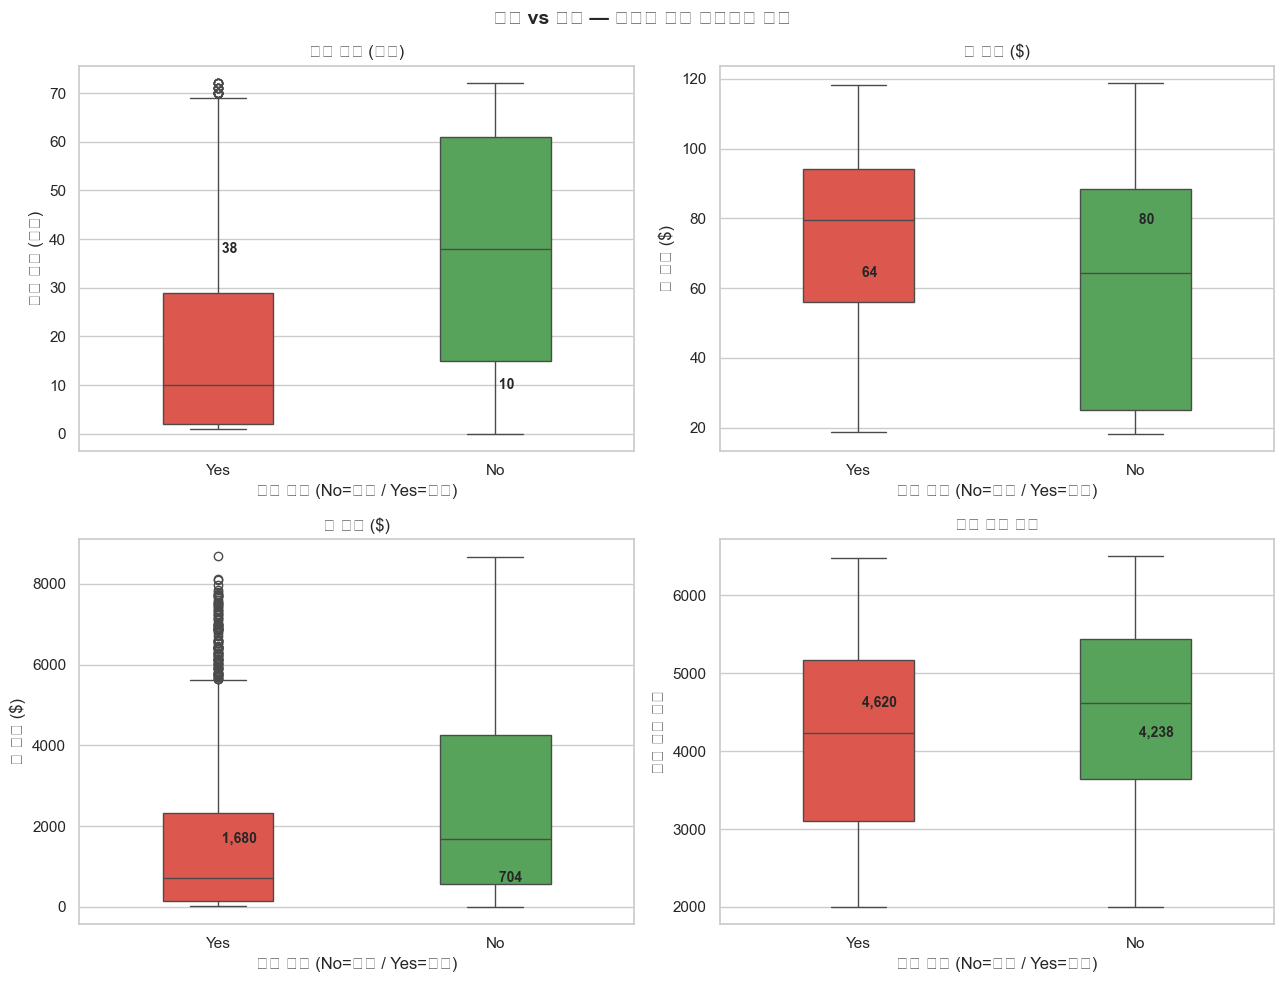

[핵심 인사이트]
- 이탈 고객 이용기간 중앙값: 10개월 vs 유지 고객: 38개월
- 이탈 고객 월 요금이 더 높음 → 요금 부담이 이탈 원인


In [59]:
num_cols   = ['Tenure Months', 'Monthly Charges', 'Total Charges', 'CLTV']
num_labels = ['이용 기간 (개월)', '월 요금 ($)', '총 요금 ($)', '고객 생애 가치']

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
fig.suptitle('이탈 vs 유지 — 수치형 변수 박스플롯 비교', fontsize=14, fontweight='bold')

for ax, col, label in zip(axes.flatten(), num_cols, num_labels):
    sns.boxplot(data=df, x='Churn Label', y=col, ax=ax,
                palette={'No':'#4CAF50','Yes':'#F44336'}, width=0.4)
    ax.set_title(label, fontsize=12)
    ax.set_xlabel('이탈 여부 (No=유지 / Yes=이탈)')
    ax.set_ylabel(label)
    # 중앙값 수치 직접 표시
    for i, grp in enumerate(['No','Yes']):
        med = df[df['Churn Label']==grp][col].median()
        ax.text(i, med, f' {med:,.0f}', va='center',
                fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print('[핵심 인사이트]')
print('- 이탈 고객 이용기간 중앙값: 10개월 vs 유지 고객: 38개월')
print('- 이탈 고객 월 요금이 더 높음 → 요금 부담이 이탈 원인')


### 2-5. 🔥 이탈 사유 대분류 + Top 10 상세

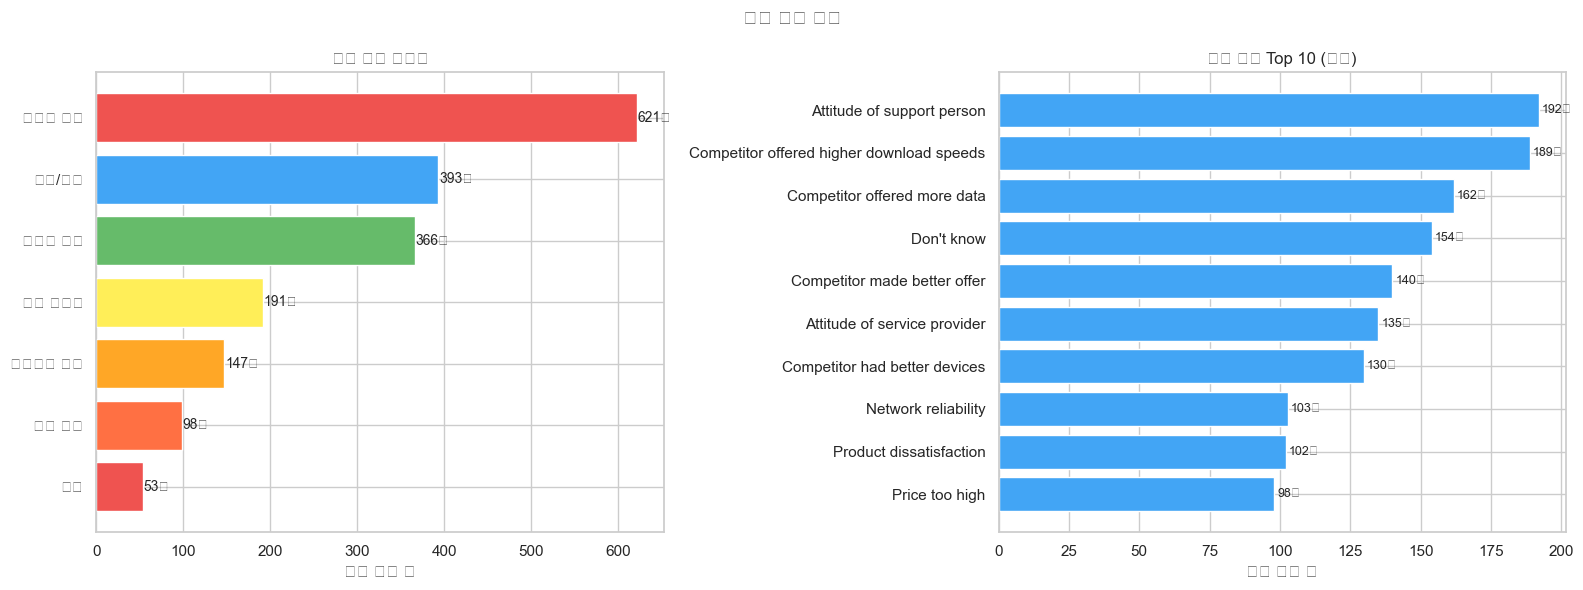

[핵심 인사이트]
1위: 고객 지원 직원 태도 문제 → 가격이 아닌 내부 서비스 품질 문제!
경쟁사 이슈: 속도/데이터/기기 → 상품 경쟁력 강화 필요


In [60]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('이탈 사유 분석', fontsize=14, fontweight='bold')

# 왼쪽: 대분류
cat_counts = (df[df['Churn Value']==1]['Churn Category']
              .value_counts().reset_index())
cat_counts.columns = ['category','count']
cat_counts = cat_counts[cat_counts['category'] != '해당없음(유지)']

colors_cat = ['#EF5350','#FF7043','#FFA726','#FFEE58','#66BB6A','#42A5F5']
bars = axes[0].barh(cat_counts['category'][::-1],
                    cat_counts['count'][::-1],
                    color=colors_cat[:len(cat_counts)], edgecolor='white')
axes[0].set_title('이탈 사유 대분류')
axes[0].set_xlabel('이탈 고객 수')
for bar in bars:
    axes[0].text(bar.get_width()+1, bar.get_y()+bar.get_height()/2,
                 f'{int(bar.get_width())}명', va='center', fontsize=10)

# 오른쪽: Top 10 상세
top10 = df['Churn Reason'].value_counts().head(10).reset_index()
top10.columns = ['reason','count']
axes[1].barh(top10['reason'][::-1], top10['count'][::-1],
             color='#42A5F5', edgecolor='white')
axes[1].set_title('이탈 사유 Top 10 (상세)')
axes[1].set_xlabel('이탈 고객 수')
for bar in axes[1].patches:
    axes[1].text(bar.get_width()+1, bar.get_y()+bar.get_height()/2,
                 f'{int(bar.get_width())}명', va='center', fontsize=9)

plt.tight_layout()
plt.show()

print('[핵심 인사이트]')
print('1위: 고객 지원 직원 태도 문제 → 가격이 아닌 내부 서비스 품질 문제!')
print('경쟁사 이슈: 속도/데이터/기기 → 상품 경쟁력 강화 필요')


### 2-6. 🏙️ 도시별 이탈 현황 — Top 15

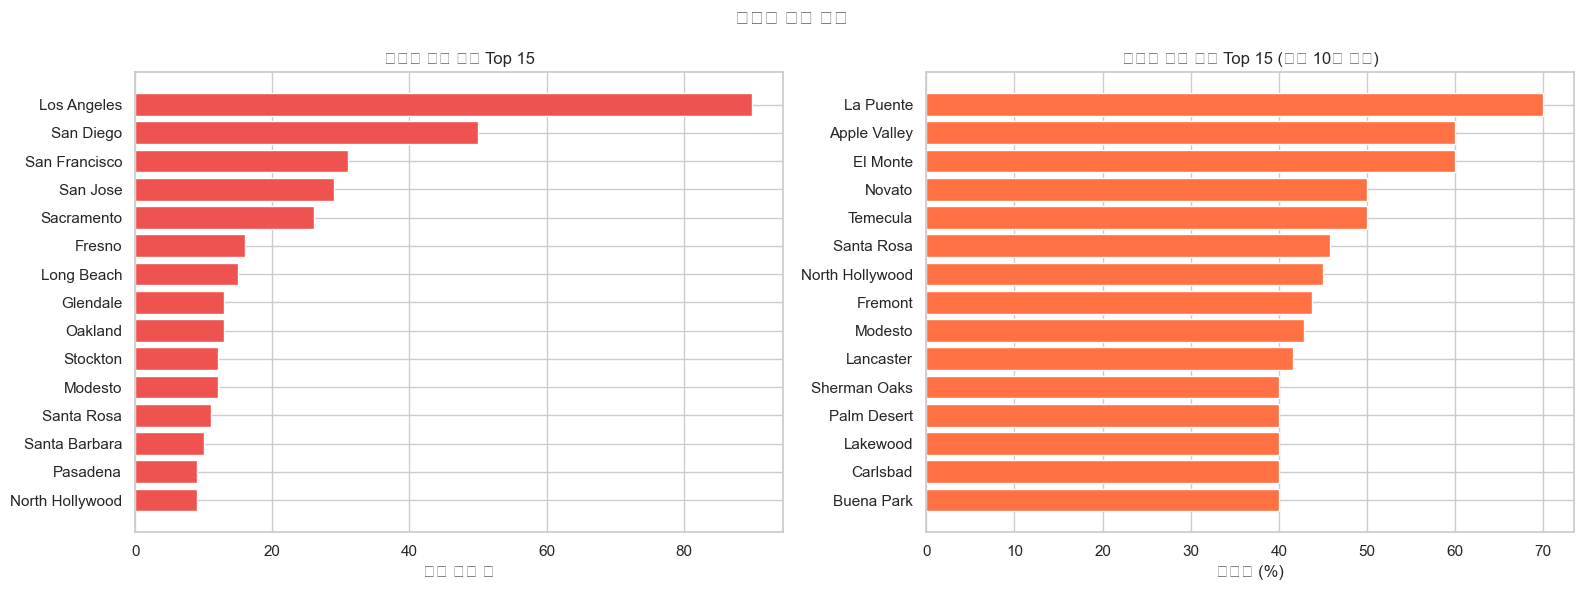

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('도시별 이탈 현황', fontsize=14, fontweight='bold')

# 왼쪽: 이탈자 수 Top 15
top_churn_city = df[df['Churn Value']==1]['City'].value_counts().head(15)
axes[0].barh(top_churn_city.index[::-1], top_churn_city.values[::-1],
             color='#EF5350', edgecolor='white')
axes[0].set_title('이탈자 많은 도시 Top 15')
axes[0].set_xlabel('이탈 고객 수')

# 오른쪽: 이탈률 Top 15 (10명 이상 도시만)
city_stats = (df.groupby('City')
                .agg(total=('Churn Value','count'), churned=('Churn Value','sum'))
                .query('total >= 10'))
city_stats['churn_rate'] = city_stats['churned'] / city_stats['total'] * 100
top_rate_city = city_stats.sort_values('churn_rate', ascending=False).head(15)

axes[1].barh(top_rate_city.index[::-1], top_rate_city['churn_rate'][::-1],
             color='#FF7043', edgecolor='white')
axes[1].set_title('이탈률 높은 도시 Top 15 (표본 10명 이상)')
axes[1].set_xlabel('이탈률 (%)')

plt.tight_layout()
plt.show()


### 2-7. 🕸️ 상관관계 네트워크 그래프

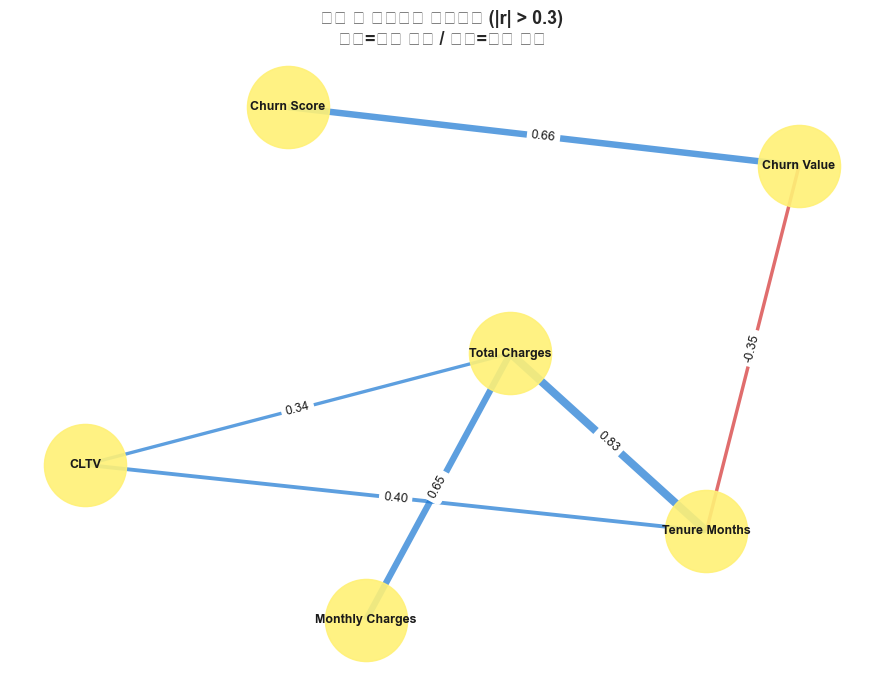

In [62]:
import networkx as nx

num_df = df[['Tenure Months','Monthly Charges','Total Charges',
             'Churn Score','CLTV','Churn Value']].copy()
corr = num_df.corr()

G = nx.Graph()
for i in range(len(corr.columns)):
    for j in range(i):
        val = corr.iloc[i, j]
        if abs(val) > 0.3:
            G.add_edge(corr.columns[i], corr.columns[j], weight=val)

plt.figure(figsize=(9, 7))
pos = nx.spring_layout(G, k=1.5, seed=42)

edge_colors = ['#1976D2' if G[u][v]['weight']>0 else '#D32F2F' for u,v in G.edges()]
edge_widths = [abs(G[u][v]['weight'])*7 for u,v in G.edges()]

nx.draw_networkx_nodes(G, pos, node_color='#FFF176', node_size=3500, alpha=0.9)
nx.draw_networkx_labels(G, pos, font_size=9, font_weight='bold')
nx.draw_networkx_edges(G, pos, edge_color=edge_colors, width=edge_widths, alpha=0.7)

edge_labels = {(u,v): f"{G[u][v]['weight']:.2f}" for u,v in G.edges()}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=9)

plt.title('변수 간 상관관계 네트워크 (|r| > 0.3)\n파랑=양의 상관 / 빨강=음의 상관',
          fontsize=13, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()


### 2-8. 🔲 복합 변수 분석 — 계약유형 × 인터넷서비스 × 이탈률

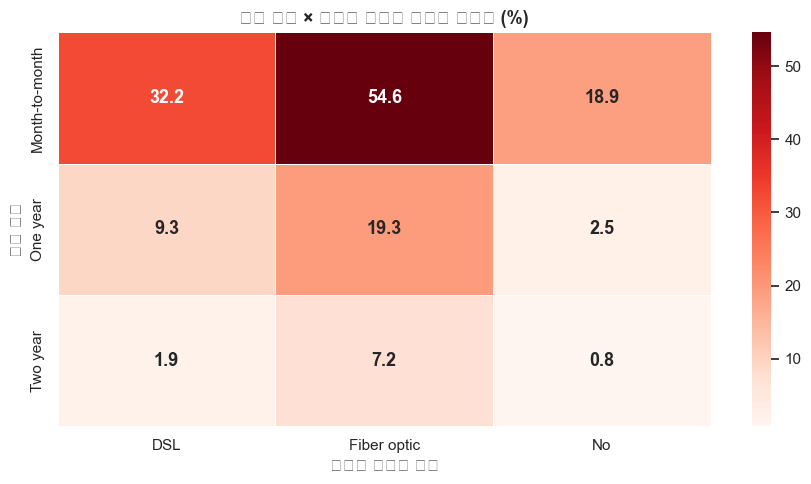

[핵심 인사이트]
Month-to-month + Fiber optic 조합: 이탈률 가장 높음
Two year + DSL/No 조합: 이탈률 가장 낮음


In [63]:
# 계약 형태 + 인터넷 서비스 조합별 이탈률 피벗 히트맵
pivot_df = df.pivot_table(
    index='Contract', columns='Internet Service',
    values='Churn Value', aggfunc='mean'
) * 100

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(pivot_df, annot=True, fmt='.1f', cmap='Reds',
            linewidths=0.5, ax=ax,
            annot_kws={'size':13, 'weight':'bold'})
ax.set_title('계약 유형 × 인터넷 서비스 조합별 이탈률 (%)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('계약 유형')
ax.set_xlabel('인터넷 서비스 종류')
plt.tight_layout()
plt.show()

print('[핵심 인사이트]')
print('Month-to-month + Fiber optic 조합: 이탈률 가장 높음')
print('Two year + DSL/No 조합: 이탈률 가장 낮음')


### 2-9. 🔵 가입 기간 × 월 요금 — 이탈 분포 산점도

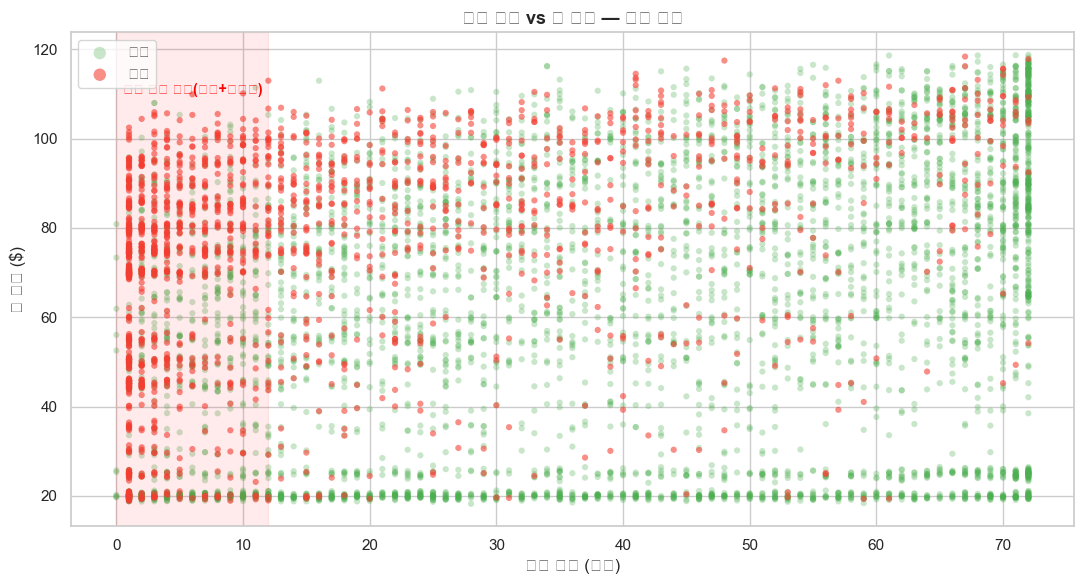

In [64]:
fig, ax = plt.subplots(figsize=(11, 6))

for label, color, name, alpha in [('No','#4CAF50','유지',0.3), ('Yes','#F44336','이탈',0.6)]:
    subset = df[df['Churn Label']==label]
    ax.scatter(subset['Tenure Months'], subset['Monthly Charges'],
               c=color, label=name, alpha=alpha, s=20, edgecolors='none')

ax.set_title('가입 기간 vs 월 요금 — 이탈 분포', fontsize=13, fontweight='bold')
ax.set_xlabel('이용 기간 (개월)')
ax.set_ylabel('월 요금 ($)')
ax.legend(markerscale=2)

# 위험 구간 표시 (단기 고객 + 고요금)
ax.axvspan(0, 12, alpha=0.08, color='red', label='단기 고객 위험 구간')
ax.text(6, 110, '⚠️ 위험 구간(단기+고요금)', ha='center', fontsize=10,
        color='red', fontweight='bold')

plt.tight_layout()
plt.show()


## 3. 🗺️ 지도 시각화 — 지역별 이탈 현황

> 위도/경도 정보를 활용해 고객 이탈을 지도 위에 표현합니다.
> 이 데이터셋에만 있는 차별화 포인트입니다.


### 3-1. 전체 고객 이탈 현황 지도 (인터랙티브)

In [65]:
# 전체 7,043명 고객을 지도에 표시
# 빨간 점 = 이탈, 파란 점  유지
fig = px.scatter_mapbox(
    df,
    lat='Latitude',
    lon='Longitude',
    color='Churn Label',
    color_discrete_map={'Yes':'#F44336', 'No':'#42A5F5'},
    hover_name='CustomerID',
    hover_data={'Churn Label':True, 'Monthly Charges':True,
                'Contract':True, 'Tenure Months':True,
                'Latitude':False, 'Longitude':False},
    zoom=5.5,
    mapbox_style='open-street-map',
    title='전체 고객 이탈 현황 지도 (빨강=이탈 / 파랑=유지)',
    height=650,
    opacity=0.6
)
fig.update_layout(margin=dict(t=50, b=0, l=0, r=0))
fig.show()


### 3-2. 도시별 이탈률 버블 지도

In [66]:
# 도시별 평균 위도/경도 + 이탈률로 버블 지도 생성
city_map = df.groupby('City').agg(
    lat=('Latitude','mean'),
    lon=('Longitude','mean'),
    total=('Churn Value','count'),
    churned=('Churn Value','sum')
).reset_index()
city_map['churn_rate'] = (city_map['churned'] / city_map['total'] * 100).round(1)
city_map = city_map[city_map['total'] >= 5]  # 표본 5명 이상만

fig = px.scatter_mapbox(
    city_map,
    lat='lat',
    lon='lon',
    size='total',           # 버블 크기 = 고객 수
    color='churn_rate',     # 색상 = 이탈률
    color_continuous_scale='Reds',
    hover_name='City',
    hover_data={'total':True, 'churned':True, 'churn_rate':True,
                'lat':False, 'lon':False},
    zoom=5.5,
    mapbox_style='open-street-map',
    title='도시별 이탈률 버블 지도 (버블 크기=고객 수 / 색상=이탈률)',
    height=650,
    size_max=40
)
fig.update_layout(margin=dict(t=50, b=0, l=0, r=0))
fig.show()


## 4. ✨ 고급 인터랙티브 시각화

> Plotly를 활용한 인터랙티브 차트로 발표 퀄리티를 높입니다.


### 4-1. 선버스트 차트 — 계약→인터넷→이탈 계층 구조

In [67]:
fig = px.sunburst(
    df,
    path=['Contract', 'Internet Service', 'Churn Label'],
    values='Count',
    color='Churn Label',
    color_discrete_map={'Yes':'#EF553B', 'No':'#636EFA'},
    title='계약 유형 → 인터넷 서비스 → 이탈 여부 계층 구조',
    height=650
)
fig.update_layout(margin=dict(t=50, b=0, l=0, r=0))
fig.show()


### 4-2. 트리맵 — 이탈 사유별 손실 CLTV

In [68]:
# 이탈 고객만 추출해서 이탈 사유별 CLTV 손실 시각화
churn_df = df[df['Churn Value'] == 1]

fig = px.treemap(
    churn_df,
    path=[px.Constant('전체 이탈 사유'), 'Churn Category', 'Churn Reason'],
    values='CLTV',
    color='CLTV',
    color_continuous_scale='RdBu_r',
    title='이탈 사유별 손실 CLTV — 박스가 클수록 손실 금액이 큼',
    height=650
)
fig.update_traces(textinfo='label+value')
fig.update_layout(margin=dict(t=50, b=0, l=0, r=0))
fig.show()


### 4-3. 레이더 차트 — 이탈 vs 유지 고객 프로필 비교

In [69]:
from sklearn.preprocessing import MinMaxScaler

features = ['Tenure Months', 'Monthly Charges', 'Churn Score', 'CLTV', 'Total Charges']
feat_kr   = ['이용 기간', '월 요금', '이탈 점수', '고객 가치', '총 요금']

df_avg = df.groupby('Churn Label')[features].mean()

# 0~1 스케일링
scaler = MinMaxScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df_avg),
                         columns=feat_kr, index=df_avg.index)

fig = go.Figure()

fig.add_trace(go.Scatterpolar(
    r=df_scaled.loc['No'].values.tolist() + [df_scaled.loc['No'].values[0]],
    theta=feat_kr + [feat_kr[0]],
    fill='toself', name='유지 고객',
    line_color='#4CAF50', fillcolor='rgba(76,175,80,0.2)'
))
fig.add_trace(go.Scatterpolar(
    r=df_scaled.loc['Yes'].values.tolist() + [df_scaled.loc['Yes'].values[0]],
    theta=feat_kr + [feat_kr[0]],
    fill='toself', name='이탈 고객',
    line_color='#F44336', fillcolor='rgba(244,67,54,0.2)'
))

fig.update_layout(
    polar=dict(radialaxis=dict(visible=True, range=[0,1])),
    showlegend=True,
    title='이탈 고객 vs 유지 고객 평균 프로필 비교 (레이더 차트)',
    height=550
)
fig.show()


### 4-4. 산키 다이어그램 — 고객 흐름 시각화

In [70]:
# 계약형태 -> 인터넷서비스 -> 이탈여부 흐름
def make_sankey(df, cols):
    levels = []
    for i in range(len(cols)-1):
        levels.append(df.groupby([cols[i], cols[i+1]]).size().reset_index(name='value'))
    all_nodes = pd.concat(
        [levels[i].iloc[:,0] for i in range(len(levels))] + [levels[-1].iloc[:,1]]
    ).unique().tolist()
    nodes_dict = {node:i for i,node in enumerate(all_nodes)}
    sources, targets, values = [], [], []
    for level in levels:
        for _, row in level.iterrows():
            sources.append(nodes_dict[row[0]])
            targets.append(nodes_dict[row[1]])
            values.append(row['value'])
    return all_nodes, sources, targets, values

nodes, src, tgt, val = make_sankey(df, ['Contract','Internet Service','Churn Label'])

fig = go.Figure(data=[go.Sankey(
    node=dict(pad=15, thickness=20,
              line=dict(color='black', width=0.5),
              label=nodes,
              color=['#EF5350' if n=='Yes' else '#42A5F5' if n=='No' else '#78909C'
                     for n in nodes]),
    link=dict(source=src, target=tgt, value=val,
              color='rgba(200,200,200,0.4)')
)])
fig.update_layout(
    title_text='고객 계약에서 이탈까지의 흐름 (Sankey Diagram)',
    font_size=12, height=600
)
fig.show()


### 4-5. 밀도 히트맵 — 이탈 위험 구간 찾기

In [71]:
fig = px.density_heatmap(
    df,
    x='Tenure Months',
    y='Monthly Charges',
    facet_col='Churn Label',
    color_continuous_scale='Reds',
    text_auto=True, # 칸마다 숫자를 표시해서 더 보기 좋게 만듭니다.
    title='이탈 여부별 가입기간 × 월요금 밀도 히트맵',
    height=550
)
fig.update_layout(margin=dict(t=60))
fig.show()

print('[읽는 법]')
print('색이 진할수록 해당 구간에 고객이 많이 몰려있음')
print('이탈(Yes) 차트에서 진한 구간 = 이탈 위험이 높은 구간')


[읽는 법]
색이 진할수록 해당 구간에 고객이 많이 몰려있음
이탈(Yes) 차트에서 진한 구간 = 이탈 위험이 높은 구간


### 4-6. 패러럴 카테고리 — 다차원 고객 경로 분석

In [72]:
fig = px.parallel_categories(
    df,
    dimensions=['Senior Citizen', 'Contract', 'Internet Service', 'Churn Label'],
    color='Churn Value',
    color_continuous_scale=px.colors.sequential.Reds,
    title='다차원 고객 군집 및 이탈 경로 분석 (Parallel Categories)',
    height=550
)
fig.show()

print('[읽는 법]')
print('선이 오른쪽 끝 Yes(이탈)로 연결되는 경로를 따라가면')
print('어떤 고객 유형이 이탈하는지 패턴을 읽을 수 있음')


[읽는 법]
선이 오른쪽 끝 Yes(이탈)로 연결되는 경로를 따라가면
어떤 고객 유형이 이탈하는지 패턴을 읽을 수 있음


### 4-7. 워드클라우드 — 이탈 사유 핵심 키워드

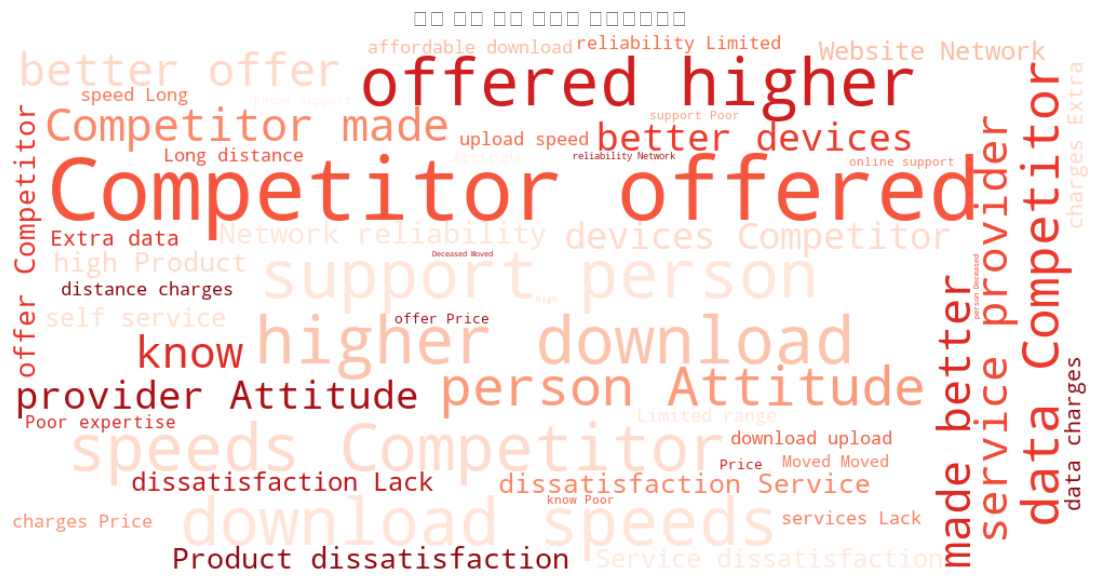

In [73]:
from wordcloud import WordCloud

text = ' '.join(df['Churn Reason'].dropna().astype(str).tolist())

wc = WordCloud(
    width=1000, height=500,
    background_color='white',
    colormap='Reds',
    max_words=60,
    prefer_horizontal=0.8
).generate(text)

plt.figure(figsize=(14, 6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('이탈 사유 핵심 키워드 워드클라우드', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


## 5. ✅ EDA 종합 요약 & 모델링 시사점


In [74]:
churn_df  = df[df['Churn Value']==1]
stay_df   = df[df['Churn Value']==0]

print('=' * 60)
print('  📋 EDA 종합 요약')
print('=' * 60)
print(f'  전체 이탈률           : {df["Churn Value"].mean()*100:.1f}%')
print(f'  이탈 고객 수          : {df["Churn Value"].sum():,}명')
print(f'  총 손실 CLTV          : ${churn_df["CLTV"].sum():,}')
print(f'  이탈자 평균 이용기간  : {churn_df["Tenure Months"].mean():.1f}개월')
print(f'  유지자 평균 이용기간  : {stay_df["Tenure Months"].mean():.1f}개월')
print(f'  이탈 1위 계약 유형    : {churn_df["Contract"].value_counts().index[0]}')
print(f'  이탈 1위 결제 방식    : {churn_df["Payment Method"].value_counts().index[0]}')
print(f'  이탈 1위 사유         : {df["Churn Reason"].value_counts().index[0]}')
print('=' * 60)
print()
print('[모델링 시사점]')
print('1. 불균형 데이터(26%) → SMOTE 처리 필수')
print('2. 핵심 예측 변수 예상: Tenure Months, Contract, Monthly Charges')
print('3. 제거할 변수:')
print('   - Churn Score, Churn Reason → 데이터 누수 위험')
print('   - City, Zip Code             → 카테고리 폭발')
print('   - Count, Country, State      → 단일값 (정보 없음)')
print('   - Lat Long                   → Latitude/Longitude 중복')
print('4. 평가 지표: Accuracy 대신 F1-Score, ROC-AUC 사용')


  📋 EDA 종합 요약
  전체 이탈률           : 26.5%
  이탈 고객 수          : 1,869명
  총 손실 CLTV          : $7,755,256
  이탈자 평균 이용기간  : 18.0개월
  유지자 평균 이용기간  : 37.6개월
  이탈 1위 계약 유형    : Month-to-month
  이탈 1위 결제 방식    : Electronic check
  이탈 1위 사유         : Attitude of support person

[모델링 시사점]
1. 불균형 데이터(26%) → SMOTE 처리 필수
2. 핵심 예측 변수 예상: Tenure Months, Contract, Monthly Charges
3. 제거할 변수:
   - Churn Score, Churn Reason → 데이터 누수 위험
   - City, Zip Code             → 카테고리 폭발
   - Count, Country, State      → 단일값 (정보 없음)
   - Lat Long                   → Latitude/Longitude 중복
4. 평가 지표: Accuracy 대신 F1-Score, ROC-AUC 사용


## 7. 📅 Tenure(이용 기간) 구간화 분석

> 이용 기간을 숫자 그대로 보는 것보다 **등급으로 나누면** 비즈니스 액션이 명확해집니다.
> - 🔴 신규 고객 (0~12개월): 이탈 위험 가장 높은 구간
> - 🟡 관찰 고객 (13~24개월): 이탈/유지 갈림길
> - 🟢 안정 고객 (25~48개월): 점점 안정화
> - 💚 충성 고객 (49개월~): 이탈 위험 낮음


=== Tenure 구간별 이탈 현황 ===
 Tenure Group  고객수  이탈수  이탈률(%)
 🔴 신규(0~12개월) 2175 1037    47.7
🟡 관찰(13~24개월) 1024  294    28.7
🟢 안정(25~48개월) 1594  325    20.4
  💚 충성(49개월~) 2239  213     9.5



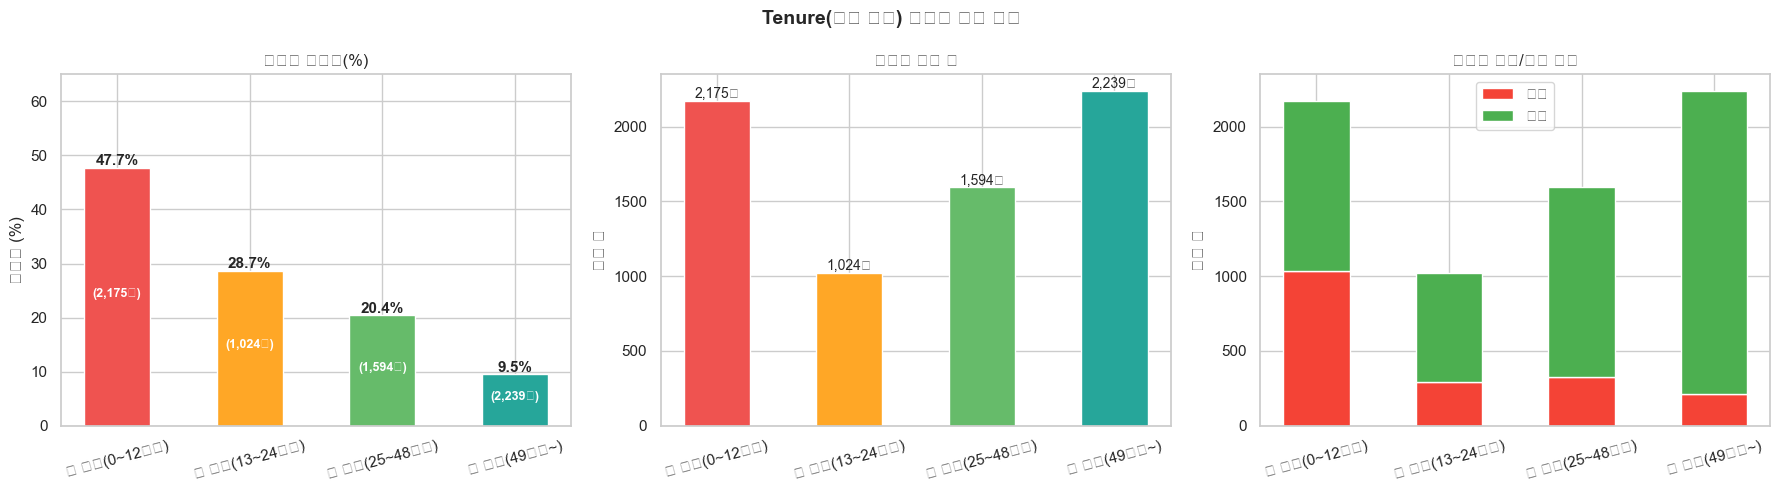

[핵심 인사이트]
- 이탈률 최고 구간: 🔴 신규(0~12개월) → 47.7%
- 이탈률 최저 구간: 💚 충성(49개월~) → 9.5%
- 신규 고객 집중 케어 프로그램이 이탈 방어의 핵심!


In [75]:
# ── Tenure 구간 나누기 ───────────────────────────────
# 0~12개월   → 신규 고객  (가입 초기, 이탈 위험 높음)
# 13~24개월  → 관찰 고객  (이탈/유지 갈림길)
# 25~48개월  → 안정 고객  (점점 정착)
# 49개월 ~   → 충성 고객  (오래된 고객, 이탈 위험 낮음)
bins   = [0, 12, 24, 48, 100]
labels = ["🔴 신규(0~12개월)", "🟡 관찰(13~24개월)",
          "🟢 안정(25~48개월)", "💚 충성(49개월~)"]

df["Tenure Group"] = pd.cut(df["Tenure Months"],
                            bins=bins, labels=labels, right=True)

# ── 구간별 고객 수 + 이탈률 계산 ────────────────────
group_stats = (df.groupby("Tenure Group", observed=True)
                 .agg(
                     고객수=("Churn Value", "count"),
                     이탈수=("Churn Value", "sum")
                 )
                 .reset_index())
group_stats["이탈률(%)"] = (group_stats["이탈수"] /
                            group_stats["고객수"] * 100).round(1)

print("=== Tenure 구간별 이탈 현황 ===")
print(group_stats.to_string(index=False))
print()

# ── 시각화 ───────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Tenure(이용 기간) 구간별 이탈 분석",
             fontsize=14, fontweight="bold")

colors = ["#EF5350", "#FFA726", "#66BB6A", "#26A69A"]

# 왼쪽: 구간별 이탈률 막대그래프
bars = axes[0].bar(group_stats["Tenure Group"],
                   group_stats["이탈률(%)"],
                   color=colors, edgecolor="white", width=0.5)
axes[0].set_title("구간별 이탈률(%)", fontsize=12)
axes[0].set_ylabel("이탈률 (%)")
axes[0].set_ylim(0, 65)
axes[0].tick_params(axis="x", rotation=15)
for bar, (_, row) in zip(bars, group_stats.iterrows()):
    # 막대 위: 이탈률
    axes[0].text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+0.5,
                 f'{row["이탈률(%)"]:.1f}%',
                 ha="center", fontsize=11, fontweight="bold")
    # 막대 안: 고객 수
    axes[0].text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()/2,
                 f'({row["고객수"]:,}명)',
                 ha="center", fontsize=9,
                 color="white", fontweight="bold")

# 가운데: 구간별 고객 수 분포
axes[1].bar(group_stats["Tenure Group"],
            group_stats["고객수"],
            color=colors, edgecolor="white", width=0.5)
axes[1].set_title("구간별 고객 수", fontsize=12)
axes[1].set_ylabel("고객 수")
axes[1].tick_params(axis="x", rotation=15)
for bar, (_, row) in zip(axes[1].patches, group_stats.iterrows()):
    axes[1].text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+20,
                 f'{row["고객수"]:,}명',
                 ha="center", fontsize=10)

# 오른쪽: 구간별 이탈/유지 누적 막대
stay_counts = group_stats["고객수"] - group_stats["이탈수"]
axes[2].bar(group_stats["Tenure Group"],
            group_stats["이탈수"],
            color="#F44336", edgecolor="white",
            width=0.5, label="이탈")
axes[2].bar(group_stats["Tenure Group"],
            stay_counts,
            bottom=group_stats["이탈수"],
            color="#4CAF50", edgecolor="white",
            width=0.5, label="유지")
axes[2].set_title("구간별 이탈/유지 구성", fontsize=12)
axes[2].set_ylabel("고객 수")
axes[2].tick_params(axis="x", rotation=15)
axes[2].legend()

plt.tight_layout()
plt.show()

# ── 핵심 인사이트 출력 ──────────────────────────────
top = group_stats.loc[group_stats["이탈률(%)"].idxmax()]
bot = group_stats.loc[group_stats["이탈률(%)"].idxmin()]
print("[핵심 인사이트]")
print(f"- 이탈률 최고 구간: {top['Tenure Group']} → {top['이탈률(%)']:.1f}%")
print(f"- 이탈률 최저 구간: {bot['Tenure Group']} → {bot['이탈률(%)']:.1f}%")
print(f"- 신규 고객 집중 케어 프로그램이 이탈 방어의 핵심!")
